##### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
import re
import spacy
import nltk
from nltk.corpus import stopwords
import plotly.express as px
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\balog\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\balog\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

##### Load the dataset

In [2]:
df_clean = pd.read_csv(r'C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Customer Feedback Analysis\Data\cleaned_reviews.csv')


In [3]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20405 entries, 0 to 20404
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        20405 non-null  int64 
 1   review_id         20405 non-null  object
 2   product_category  20405 non-null  object
 3   timestamp         20157 non-null  object
 4   country           20405 non-null  object
 5   rating            20405 non-null  int64 
 6   review            20405 non-null  object
 7   sentiment         20405 non-null  object
 8   language          20405 non-null  object
 9   processed_review  20405 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.6+ MB


##### Train Baseline Sentiment Models

- Prepare Features and Target

In [11]:
X = df_clean["processed_review"]
y = df_clean["sentiment"]

- Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (16324,)
Testing Size: (4081,)


        Stratification is used to ensure the sentiment proportion is identical in train and test splits.

- TD-IF Vectorization - converts text into numbers that machine learning models can understand.

In [13]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(16324, 5000)
(4081, 5000)


- Balance Training Data for the target variable (Sentiment) with SMOTE

In [14]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)
print(y_train_balanced.value_counts())

sentiment
Negative    11325
Positive    11325
Neutral     11325
Name: count, dtype: int64


- Naive Bayes


--- Naive Bayes Results ---
Accuracy: 0.8329
Precision: 0.8899
Recall: 0.8329
F1-Score: 0.8581
ROC-AUC: 0.9436
Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.87      0.90      2831
     Neutral       0.12      0.34      0.18       165
    Positive       0.88      0.80      0.84      1085

    accuracy                           0.83      4081
   macro avg       0.65      0.67      0.64      4081
weighted avg       0.89      0.83      0.86      4081

Confusion Matrix:
[[2472  282   77]
 [  65   56   44]
 [  95  119  871]]


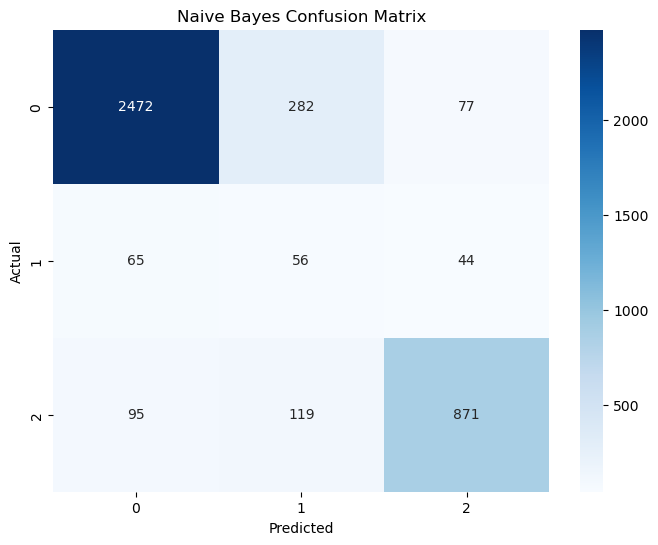

--------------------------------------------------


In [15]:
# Create a Multinomial Naive Bayes model
nb_model = MultinomialNB()

#Train the model
nb_model.fit(X_train_balanced, y_train_balanced)

# Predict 
y_pred_nb = nb_model.predict(X_test_tfidf)
y_prob_nb = nb_model.predict_proba(X_test_tfidf)

#Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted')
recall_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')
roc_auc_nb = roc_auc_score(y_test, y_prob_nb, multi_class='ovr', average='weighted')
report_nb = classification_report(y_test, y_pred_nb)
matrix_nb = confusion_matrix(y_test, y_pred_nb)

print(f"\n--- Naive Bayes Results ---")
print("Accuracy:", f"{accuracy_nb:.4f}")
print("Precision:", f"{precision_nb:.4f}")
print("Recall:", f"{recall_nb:.4f}")
print("F1-Score:", f"{f1_nb:.4f}")
print("ROC-AUC:", f"{roc_auc_nb:.4f}")
print("Classification Report:")
print(report_nb)
print("Confusion Matrix:")
print(matrix_nb)

#Plot confusion matrix bbvc
plt.figure(figsize=(8,6))
sns.heatmap(matrix_nb, annot=True, fmt="d", cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("-" * 50)

        The Naïve Bayes model achieved 83.29% accuracy, 88.99% precision, 83.29% recall, 85.81% F1-Score and 94.36% ROC-AUC, performing very well on Negative and Positive reviews but struggling to correctly identify Neutral reviews due to overlapping language patterns and class imbalance, resulting in high Neutral false positives and false negatives despite SMOTE balancing.  

- Logistic Regression


--- Logistic Regression Results ---
Accuracy: 0.8495
Precision: 0.8907
Recall: 0.8495
F1-Score: 0.8681
ROC-AUC: 0.9451
Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.89      0.92      2831
     Neutral       0.13      0.31      0.19       165
    Positive       0.87      0.82      0.84      1085

    accuracy                           0.85      4081
   macro avg       0.65      0.67      0.65      4081
weighted avg       0.89      0.85      0.87      4081

Confusion Matrix:
[[2528  212   91]
 [  76   51   38]
 [  81  116  888]]


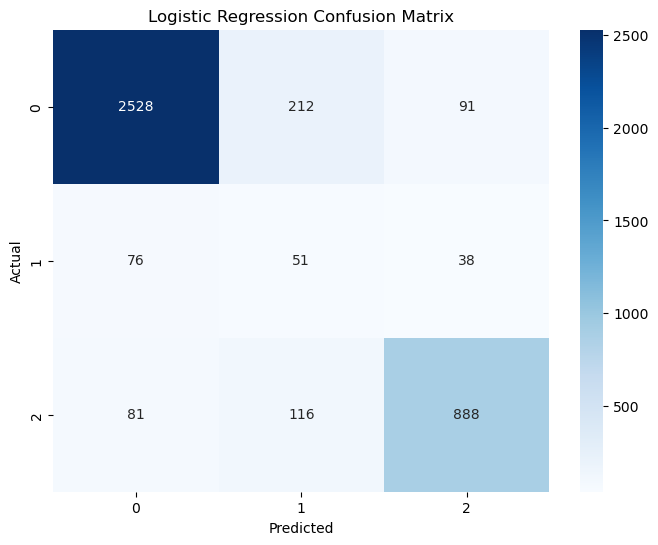

--------------------------------------------------


In [16]:
# Create a Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

#Train the model
lr_model.fit(X_train_balanced, y_train_balanced)

# Predict 
y_pred_lr = lr_model.predict(X_test_tfidf)
y_prob_lr = lr_model.predict_proba(X_test_tfidf)

#Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
roc_auc_lr = roc_auc_score(y_test, y_prob_lr, multi_class='ovr', average='weighted')
report_lr = classification_report(y_test, y_pred_lr)
matrix_lr = confusion_matrix(y_test, y_pred_lr)

print(f"\n--- Logistic Regression Results ---")
print("Accuracy:", f"{accuracy_lr:.4f}")
print("Precision:", f"{precision_lr:.4f}")
print("Recall:", f"{recall_lr:.4f}")
print("F1-Score:", f"{f1_lr:.4f}")
print("ROC-AUC:", f"{roc_auc_lr:.4f}")
print("Classification Report:")
print(report_lr)
print("Confusion Matrix:")
print(matrix_lr)

#Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(matrix_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("-" * 50)

      Logistic Regression achieved 84.95% accuracy, 89.07% precision, 84.95% recall, 86.81% F1 score, 94.51% ROC AUC and outperformed Naïve Bayes in all matirx, showing excellent performance on Negative and Positive reviews. However, Neutral reviews remain difficult to classify due to overlapping sentiment language, resulting in high Neutral false positives and false negatives despite SMOTE balancing.

- Linear SVM


--- Support Vector Machine Results ---
Accuracy: 0.8562
Precision: 0.8815
Recall: 0.8562
F1-Score: 0.8679
ROC-AUC: 0.9399
Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.90      0.92      2831
     Neutral       0.13      0.23      0.16       165
    Positive       0.87      0.82      0.85      1085

    accuracy                           0.86      4081
   macro avg       0.64      0.65      0.64      4081
weighted avg       0.88      0.86      0.87      4081

Confusion Matrix:
[[2562  174   95]
 [  87   38   40]
 [ 105   86  894]]


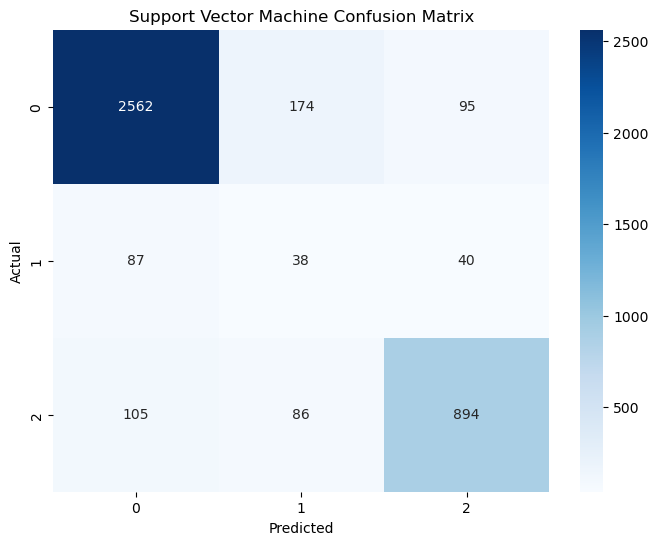

--------------------------------------------------


In [17]:
# Create a Support Vector Machine (SVM) model
svm_model = SVC(kernel="linear", probability=True)

#Train the model
svm_model.fit(X_train_balanced, y_train_balanced)

# Predict 
y_pred_svm = svm_model.predict(X_test_tfidf)
y_prob_svm = svm_model.predict_proba(X_test_tfidf)

#Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')
roc_auc_svm = roc_auc_score(y_test, y_prob_svm, multi_class='ovr', average='weighted')
report_svm = classification_report(y_test, y_pred_svm)
matrix_svm = confusion_matrix(y_test, y_pred_svm)

print(f"\n--- Support Vector Machine Results ---")
print("Accuracy:", f"{accuracy_svm:.4f}")
print("Precision:", f"{precision_svm:.4f}")
print("Recall:", f"{recall_svm:.4f}")
print("F1-Score:", f"{f1_svm:.4f}")
print("ROC-AUC:", f"{roc_auc_svm:.4f}")
print("Classification Report:")
print(report_svm)
print("Confusion Matrix:")
print(matrix_svm)

#Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(matrix_svm, annot=True, fmt="d", cmap="Blues")
plt.title("Support Vector Machine Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("-" * 50)

     Linear SVM achieved the highest accuracy (85.62%), 88.15% precision, 85.62% recall, 86.79% F1 score, 93.99% ROC AUC and delivered the strongest performance for Negative and Positive sentiment classification. However, it performed poorly on Neutral reviews, producing high false positives and false negatives. If the objective is overall sentiment prediction, SVM is the preferred model. If Neutral sentiment identification is important, Logistic Regression or Naïve Bayes may be more suitable.